Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg
jlPkg.activate(".")
jl.Pkg.instantiate()
jl.include("models/rl_repressilator_past_amort_setup.jl")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `c:\Users\micha\GeneCircuitsRL`


Second peak value: 0.7038096038235359


observation (generic function with 2 methods)

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class Custom1DCNNExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128, obs_dim=128, action_dim=3, n_steps=5):
        super(Custom1DCNNExtractor, self).__init__(observation_space, features_dim)

        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.n_steps = n_steps

        n_input_channels = 1
        seq_len = obs_dim

        self.cnn = nn.Sequential(
            nn.Conv1d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        with th.no_grad():
            sample_obs = th.zeros((1, n_input_channels, seq_len), dtype=th.float32)
            cnn_output_dim = self.cnn(sample_obs).shape[1]

        # Concatenate obs features and raw actions across all steps
        combined_dim = self.n_steps * cnn_output_dim + self.n_steps * action_dim

        self.linear = nn.Sequential(
            nn.Linear(combined_dim, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        """
        observations: (batch, 1, obs1 + act1 + ... + obsN + actN)
        """
        obs_feats = []
        act_feats = []

        for i in range(self.n_steps):
            obs_start = i * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            act_end = act_start + self.action_dim

            obs = observations[:, :, obs_start:act_start]  # (batch, 1, obs_dim)
            act = observations[:, 0, act_start:act_end]    # (batch, action_dim)

            obs_feat = self.cnn(obs)                       # (batch, cnn_output_dim)
            obs_feats.append(obs_feat)
            act_feats.append(act)

        combined = th.cat(obs_feats + act_feats, dim=1)
        return self.linear(combined)

import random
import torch
from gymnasium.utils import seeding

class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        self.obs_dim = 128
        self.action_dim = 3          # design params: kX, km, K
        self.uncertain_dim = 4       # H, γX, γm, ϵ
        self.n_steps = max_episode_steps

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32
        )

        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)

        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)
    
    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]
    
    def reset(self, seed=None, options=None):
        if options is not None and 'uncertain' in options:
            self.uncertain = np.array(options['uncertain'], dtype=np.float32)
        else:
            self.uncertain = (np.random.rand(self.uncertain_dim) * 2 - 1).astype(np.float32)

        if seed is not None:
            self.seed(seed)
        
        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    def step(self, action):
        params_action = np.concatenate((self.uncertain, action))
        reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
        rew = np.clip(reward, -5, 5)

        obs_vector = jl.observation(self.uncertain, action)
        obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim

            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), rew, terminated, truncated, info


In [3]:
from stable_baselines3.common.env_checker import check_env
env = CustomEnv()
check_env(env)

c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\stable_baselines3\common\env_checker.py:316: UserWarning: Your observation  has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(


Training

In [ ]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5_1234/"
os.makedirs(log_dir, exist_ok=True)


SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")  # Julia seed
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

policy_kwargs = dict(
    features_extractor_class=Custom1DCNNExtractor,
    features_extractor_kwargs=dict(features_dim=128),
)

model = PPO(
    "CnnPolicy", 
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    tensorboard_log=log_dir,
    seed=SEED
)



Using cpu device
Wrapping the env in a DummyVecEnv.


In [ ]:
model.learn(total_timesteps=1500000)
obs, info = env.reset()
action, _ = model.predict(obs)
print("Test action:", action)

Logging to logs/rl_repressilator_past_amort_multi_step_frame_5_1234/PPO_1


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | -0.322   |
| time/              |          |
|    fps             | 10       |
|    iterations      | 1        |
|    time_elapsed    | 200      |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5           |
|    ep_rew_mean          | -0.711      |
| time/                   |             |
|    fps                  | 10          |
|    iterations           | 2           |
|    time_elapsed         | 402         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005601207 |
|    clip_fraction        | 0.0703      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.24       |
|    explained_variance   | -0.00551    |
|    learning_rate        | 0.

In [9]:
model.save(os.path.join(log_dir, "ppo_model"))

Evaluation

In [ ]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5_1234"
model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

df = pd.read_csv(monitor_file, skiprows=1)  

In [5]:
model = PPO.load(model_path)


C:\Users\micha\AppData\Local\Temp\ipykernel_51252\1846774193.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


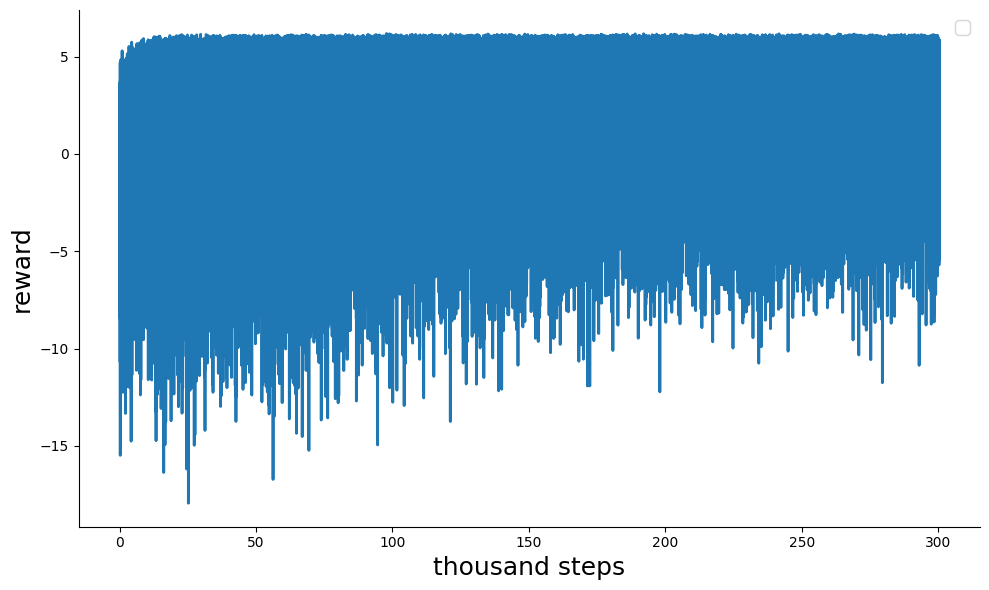

In [6]:

plt.figure(figsize=(10, 6))
sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_3.pdf", format="pdf")
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_51252\4038937236.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [-1.  1.  1.]
False
First reward: 0.05211822810859662
(1, 655)
Action taken: [-1.         -0.38115454  1.        ]
Second reward: 1.1702987286698632
Action taken: [-1.         -0.24507254  1.        ]
Third reward: 0.6082819287850525
False


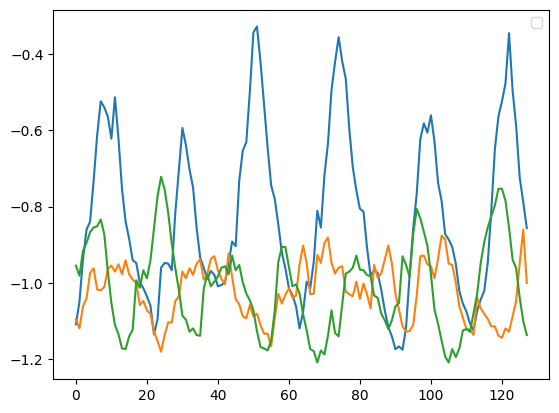

In [8]:
obs, info = env.reset()  # Reset the environment with a specific frequency

action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()
# Take action in the environment

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

plt.plot(obs[0,0:128], label="First Design")
plt.plot(obs[0,132:260], label="Second Design")

action, _states = model.predict(obs, deterministic=True)

plt.plot(jl.observation(env.uncertain, action), label="Third Design")

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)




In [8]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5



Text(0, 0.5, 'Reward')

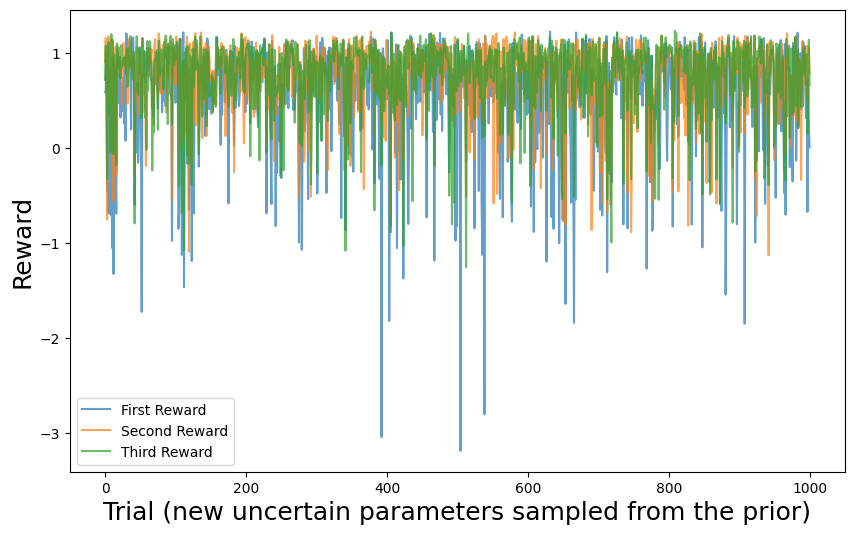

In [9]:

plt.figure(figsize=(10, 6))
plt.plot(first_rewards, label='First Reward', alpha=0.7)
plt.plot(second_rewards, label='Second Reward', alpha=0.7)
plt.plot(third_rewards, label='Third Reward', alpha=0.7)
plt.legend()
plt.xlabel("Trial (new uncertain parameters sampled from the prior)", fontsize=18)
plt.ylabel("Reward", fontsize=18)


Text(0, 0.5, 'Reward')

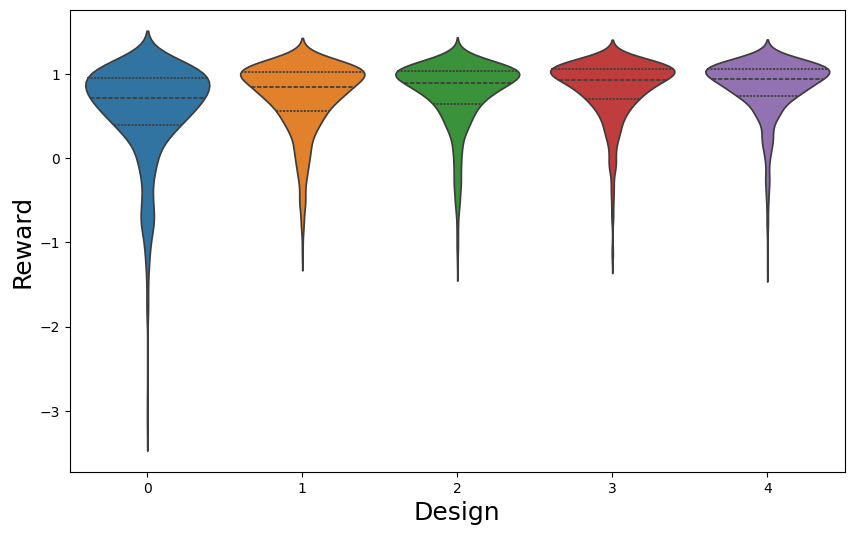

In [10]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile")
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)


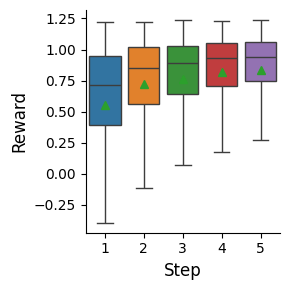

In [ ]:

plt.figure(figsize=(3, 3))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], showmeans=True, showfliers = False)

plt.xticks(ticks=range(5), labels=["1", "2", "3", "4", "5"])

plt.xlabel("Step", fontsize=12)
plt.ylabel("Reward", fontsize=12)

sns.despine()
plt.tight_layout()
# plt.savefig("boxes_std.pdf", format="pdf")
plt.show()

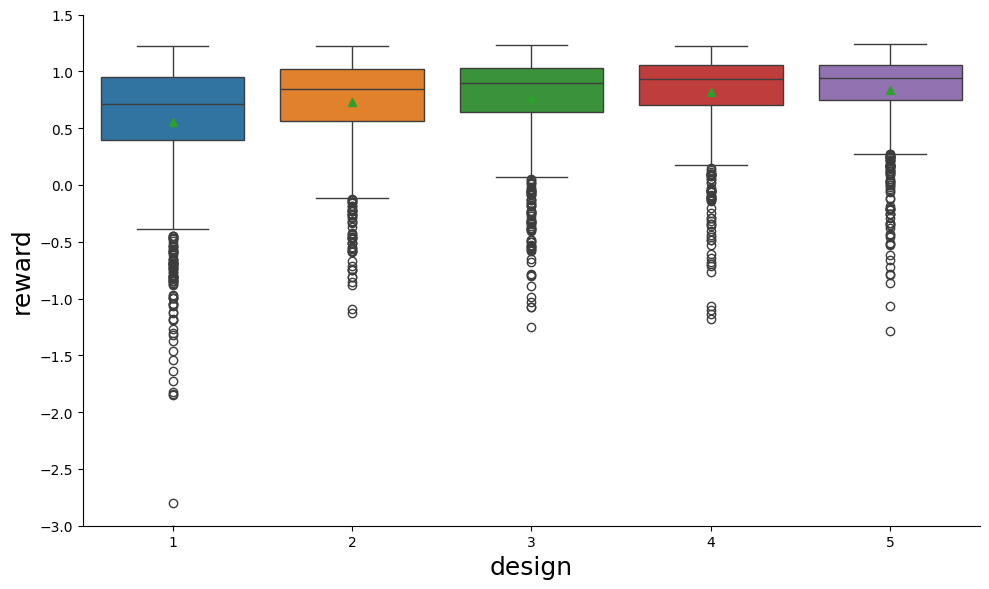

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], showmeans=True)

plt.xticks(ticks=range(5), labels=["1", "2", "3", "4", "5"])

plt.xlabel("design", fontsize=18)
plt.ylabel("reward", fontsize=18)

sns.despine()
plt.ylim(-3,1.5)
plt.tight_layout()
plt.savefig("boxes_std_2.pdf", format="pdf")
plt.show()

Action taken: [-1.  1.  1.]
False
First reward: 0.6119223480904863
(1, 655)
Action taken: [-1.          1.         -0.12393731]
Second reward: 1.1923722853731797
Action taken: [-1.         1.        -0.0164305]
Third reward: 0.9944386387853937
False
Action taken: [-1.0000000e+00  1.0000000e+00 -3.6679208e-04]
Forth reward: 1.20716664532125
False


C:\Users\micha\AppData\Local\Temp\ipykernel_28324\114822999.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [-1.          1.         -0.06123507]
Fifth reward: 0.9916015350899855
True
0.6073570465888714


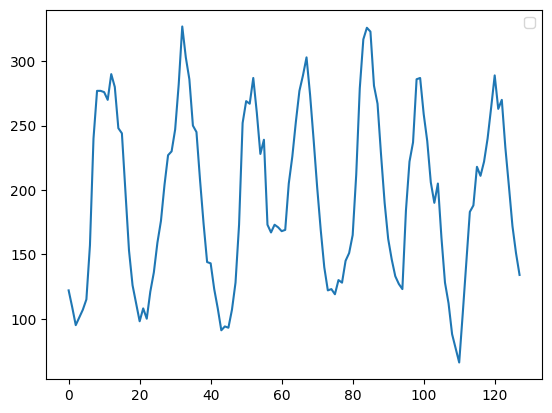

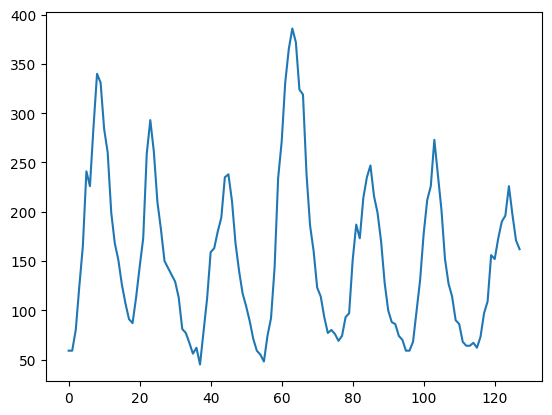

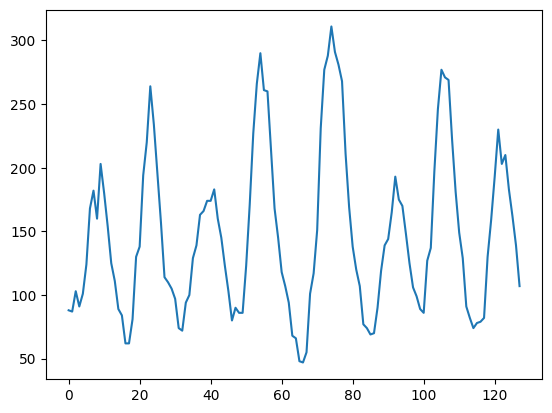

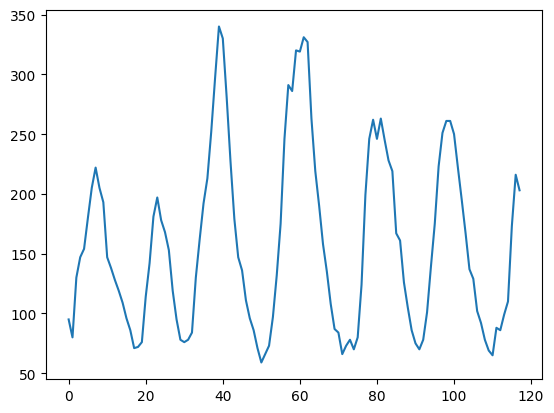

In [ ]:
np.random.seed(0)
obs, info = env.reset(12)
# env.uncertain =1*  np.ones(4)
action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

action, _states = model.predict(obs, deterministic=True)
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Forth reward:", reward)


print(terminated)


action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Fifth reward:", reward)


print(terminated)
action, _states = model.predict(obs, deterministic=True)
params_action = np.concatenate((env.uncertain, action))
reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
print(reward)

plt.plot(jl.observation_denormalized(obs[0,0:128]), label="First Design")
plt.show()
plt.plot(jl.observation_denormalized(obs[0,131:259]), label="Second Design")
plt.show()

plt.plot(jl.observation_denormalized(obs[0,262:390]), label="Third Design")
plt.show()

plt.plot(jl.observation_denormalized(obs[0,533:651]), label="Forth Design")
plt.show()


Action taken: [-1.  1.  1.]
False
First reward: 0.5595805964131921
(1, 655)
Action taken: [-1.         -0.58524597  1.        ]
Second reward: 0.25776948822804097


C:\Users\micha\AppData\Local\Temp\ipykernel_28324\1456528895.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [-1.         -0.56077427  1.        ]
Third reward: -0.3165168124550841
False
Action taken: [-1.        -0.7751664  1.       ]
Forth reward: 0.2108501561653202
False
Action taken: [-1.        -0.7289941  1.       ]
Fifth reward: 1.0051996452424328
True


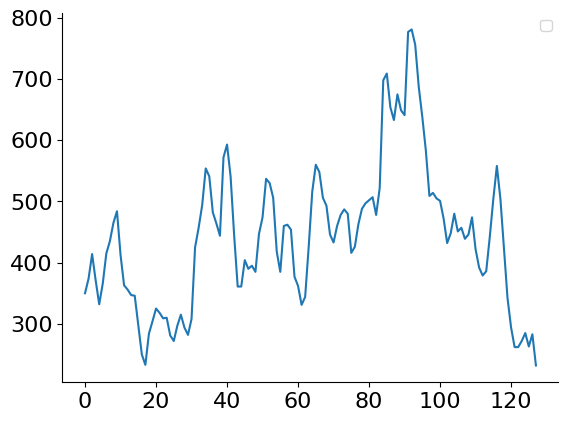

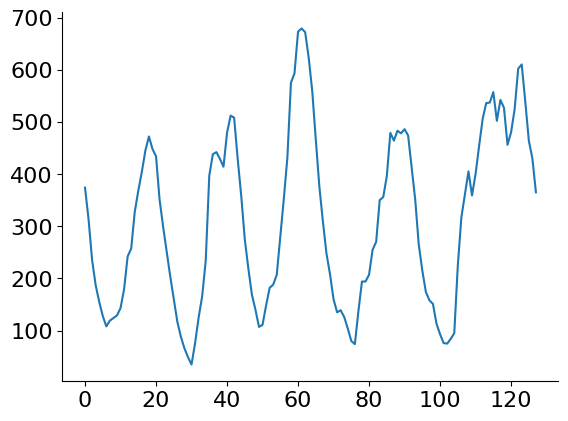

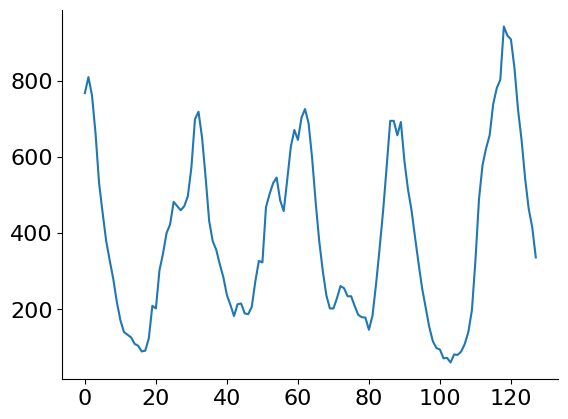

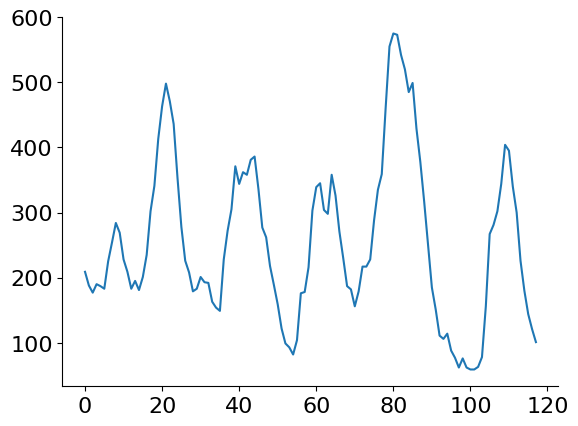

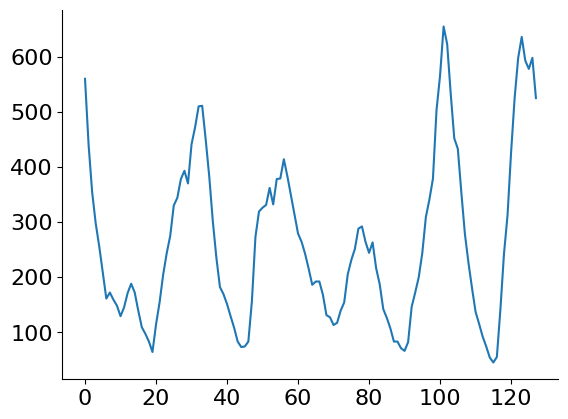

In [ ]:
np.random.seed(0)
obs, info = env.reset(2) 
env.uncertain =[0,0.0,-1,0]
action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

action, _states = model.predict(obs, deterministic=True)
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Forth reward:", reward)


print(terminated)


action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

action, _states = model.predict(obs, deterministic=True)

print("Action taken:", action)
print("Fifth reward:", reward)


print(terminated)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,0:128]), label="First Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,131:259]), label="Second Design")
sns.despine()
plt.show()
sns.despine()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,262:390]), label="Third Design")
sns.despine()
plt.show()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.plot(jl.observation_denormalized(obs[0,533:651]), label="Forth Design")
sns.despine()
plt.show()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(jl.observation(env.uncertain, action)), label="Fifth Design")
sns.despine()
plt.show()



In [123]:
obs[0].shape

(655,)

Action taken: [-1.  1.  1.]
False
First reward: 0.9697952494280816
(1, 655)
Action taken: [-1.          1.         -0.43881533]
Second reward: 0.9827107458600491
Action taken: [-1.          1.         -0.42233428]
Third reward: 0.7909199068368882
False
Action taken: [-1.          1.         -0.42165723]
Forth reward: 1.1650323767960185
False


C:\Users\micha\AppData\Local\Temp\ipykernel_28324\592964502.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [-1.          1.         -0.40081164]
Fifth reward: 0.9456078603828744
True


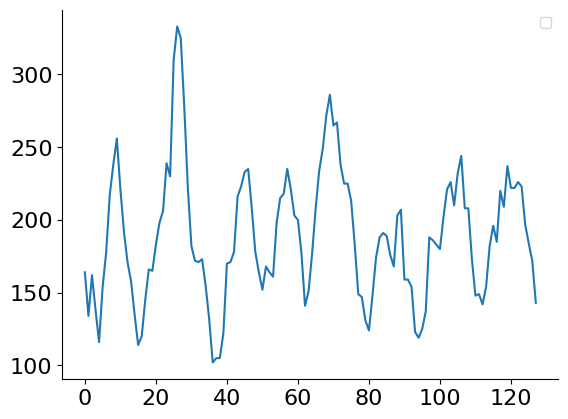

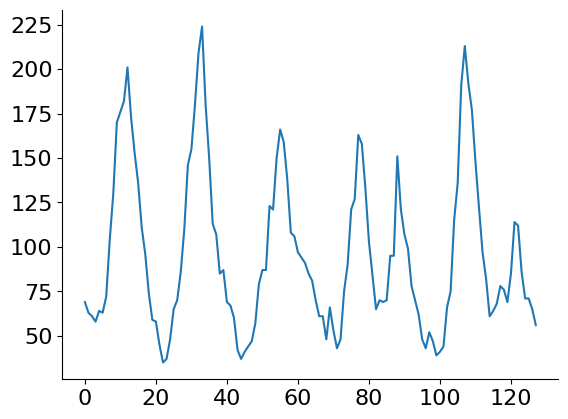

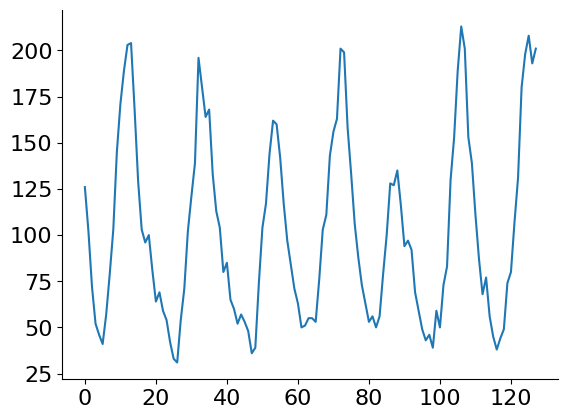

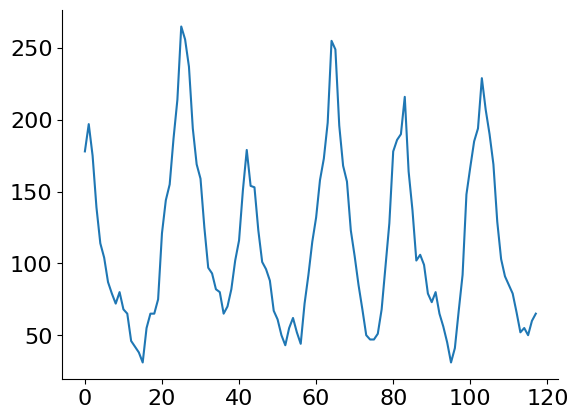

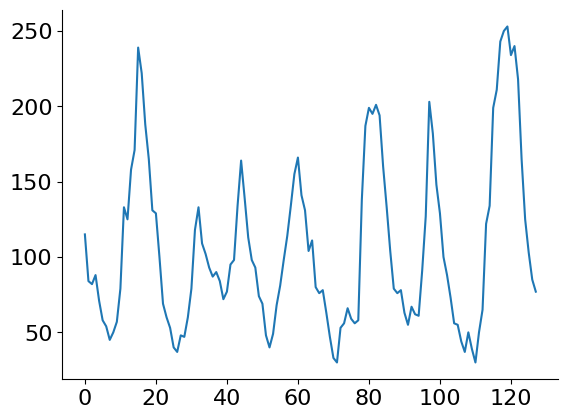

In [ ]:
np.random.seed(0)
obs, info = env.reset(1) 
env.uncertain = [1,1,0.5,1]

action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))

obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

plt.legend()

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

action, _states = model.predict(obs, deterministic=True)
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Forth reward:", reward)


print(terminated)


action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

action, _states = model.predict(obs, deterministic=True)

print("Action taken:", action)
print("Fifth reward:", reward)


print(terminated)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,0:128]), label="First Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,131:259]), label="Second Design")
sns.despine()
plt.show()
sns.despine()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,262:390]), label="Third Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,533:651]), label="Forth Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(jl.observation(env.uncertain, action)), label="Fifth Design")
sns.despine()
plt.show()



Action taken: [-1.  1.  1.]
False
First reward: 0.8283002271054491
(1, 655)
Action taken: [-1.        -0.6980561  1.       ]
Second reward: 1.0346526876126243
Action taken: [-1.         -0.64507747  1.        ]
Third reward: 0.6324682613090522
False


C:\Users\micha\AppData\Local\Temp\ipykernel_28324\2218989425.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [-1.        -0.7328436  1.       ]
Forth reward: 1.2256349870345042
False
Action taken: [-1.         -0.76453704  1.        ]
Fifth reward: 0.7973684765354538
True


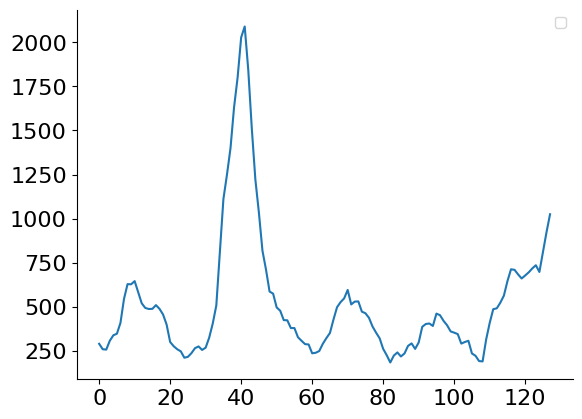

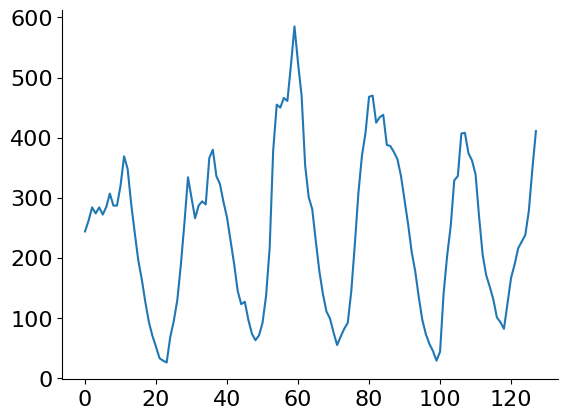

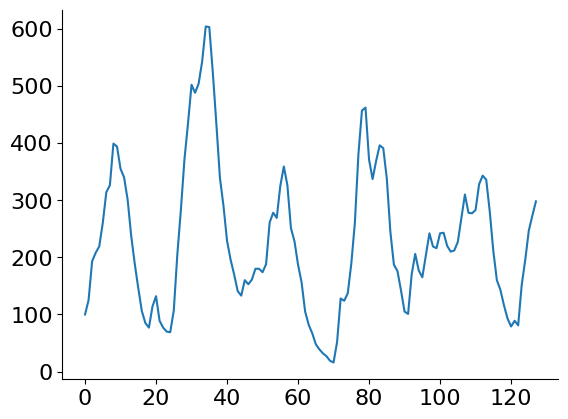

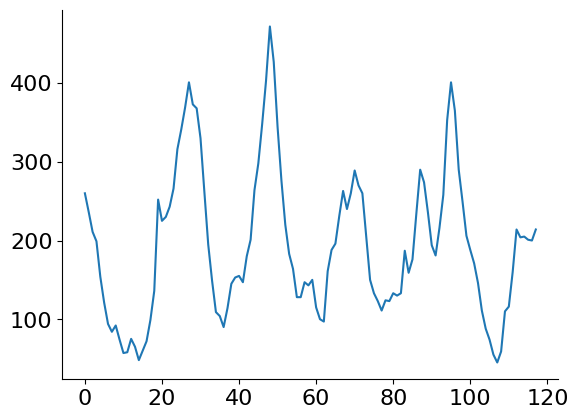

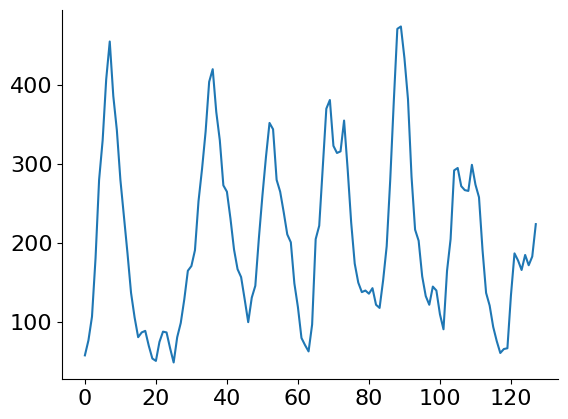

In [ ]:
np.random.seed(0)
obs, info = env.reset(0)  
env.uncertain = [0,1,-1,0]
action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

action, _states = model.predict(obs, deterministic=True)
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Forth reward:", reward)


print(terminated)


action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

action, _states = model.predict(obs, deterministic=True)

print("Action taken:", action)
print("Fifth reward:", reward)


print(terminated)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.plot(jl.observation_denormalized(obs[0,0:128]), label="First Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.plot(jl.observation_denormalized(obs[0,131:259]), label="Second Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
sns.despine()
plt.plot(jl.observation_denormalized(obs[0,262:390]), label="Third Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(obs[0,533:651]), label="Forth Design")
sns.despine()
plt.show()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation_denormalized(jl.observation(env.uncertain, action)), label="Fifth Design")
sns.despine()
plt.show()

Action taken: [-1.  1.  1.]
False
First reward: 0.9763336416383155
(1, 655)
Action taken: [-1.         1.        -0.3935167]
Second reward: 0.4108961226441572


C:\Users\micha\AppData\Local\Temp\ipykernel_28324\3726433188.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


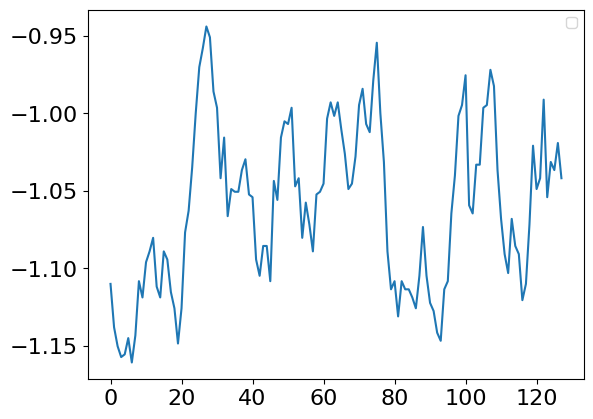

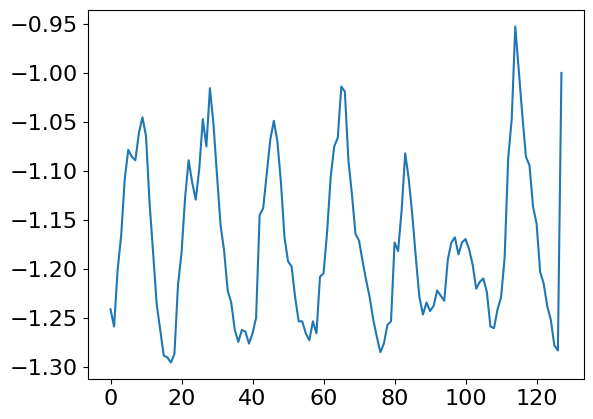

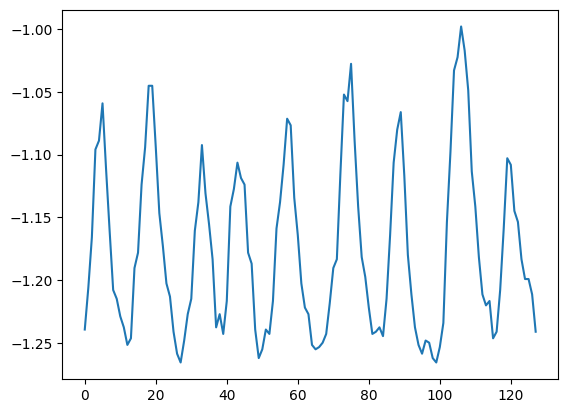

Action taken: [-1.          1.         -0.24557787]
Third reward: 0.40490467379230854
False


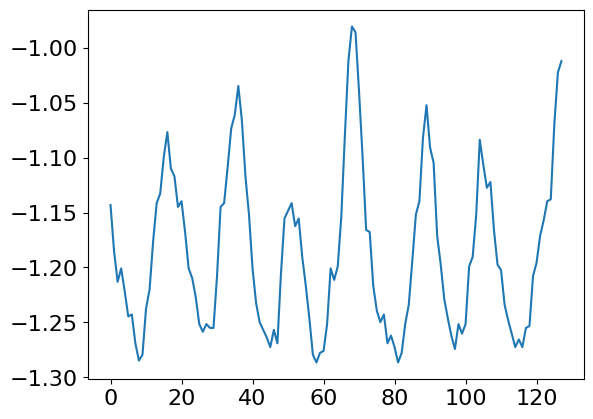

Action taken: [-1.          1.         -0.37909052]
forth reward: 0.6014851194938463
False


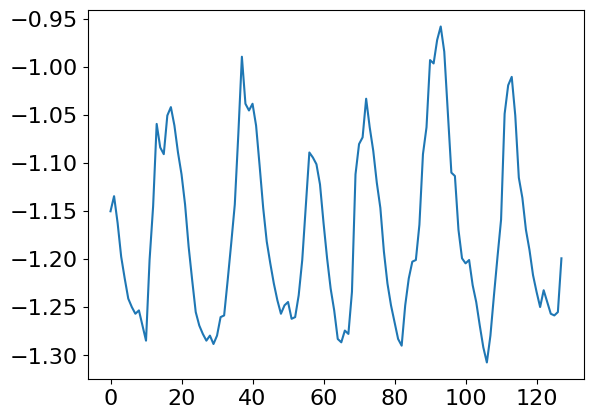

Action taken: [-1.          1.         -0.43700173]
Fifth reward: 0.8134651599461546
True


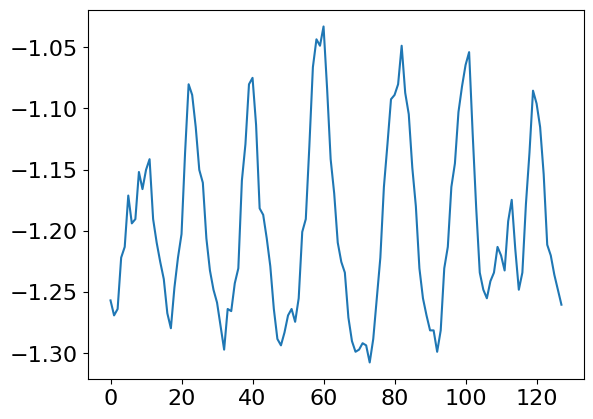

In [ ]:
obs, info = env.reset(1234) 
env.uncertain = np.ones(4)
action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))

obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

plt.legend()
action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(obs[0,0:128], label="First Design")
plt.show()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(obs[0,132:260], label="Second Design")
plt.show()
action, _states = model.predict(obs, deterministic=True)

plt.plot(jl.observation(env.uncertain, action), label="Third Design")
plt.show()
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)

action, _states = model.predict(obs, deterministic=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation(env.uncertain, action), label="Third Design")
plt.show()
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("forth reward:", reward)


print(terminated)


action, _states = model.predict(obs, deterministic=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(jl.observation(env.uncertain, action), label="Third Design")
plt.show()
obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Fifth reward:", reward)


print(terminated)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
action, _states = model.predict(obs, deterministic=True)
plt.plot(jl.observation(env.uncertain, action), label="Fifth Design")




PermissionError: [Errno 13] Permission denied: 'boxes_std.pdf'

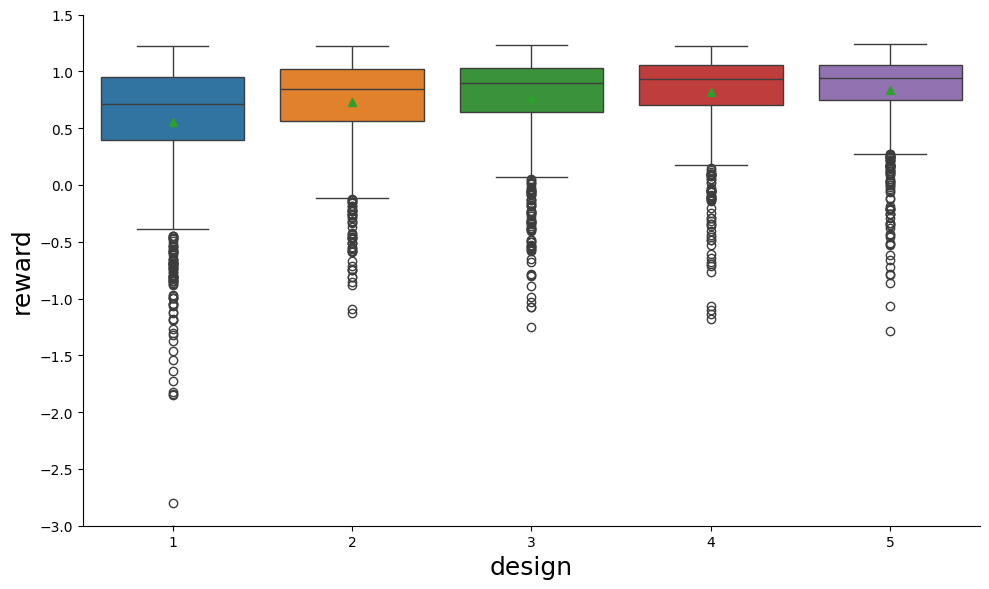

In [64]:
# Plot boxplot with seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], showmeans=True)

# Set x-axis labels starting from 1
plt.xticks(ticks=range(5), labels=["1", "2", "3", "4", "5"])

plt.xlabel("design", fontsize=18)
plt.ylabel("reward", fontsize=18)

sns.despine()
plt.ylim(-3,1.5)
plt.tight_layout()
plt.savefig("boxes_std.pdf", format="pdf")
plt.show()

PermissionError: [Errno 13] Permission denied: 'boxes_std.pdf'

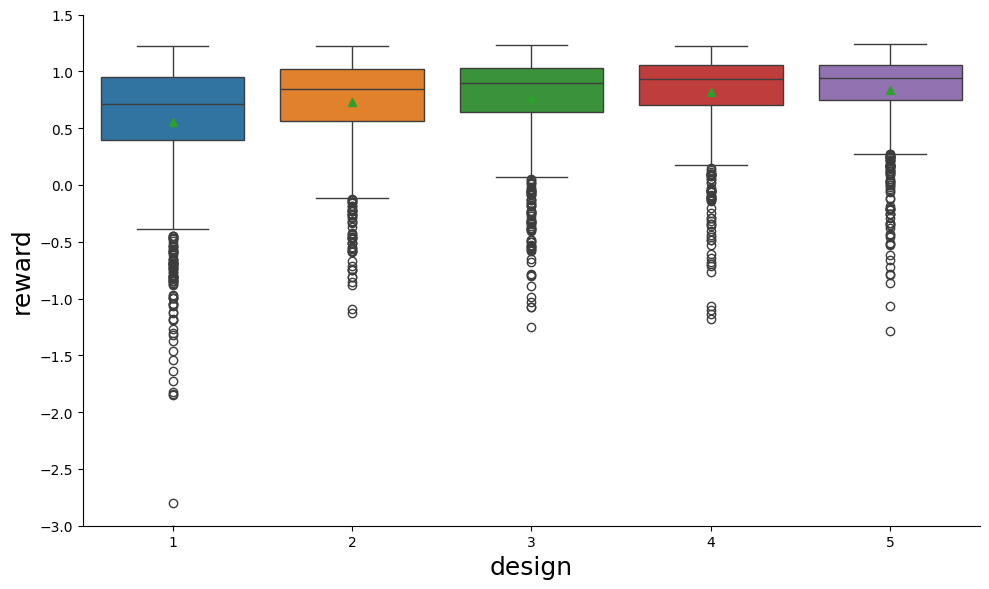

In [63]:
# Plot boxplot with seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], showmeans=True)

# Set x-axis labels starting from 1
plt.xticks(ticks=range(5), labels=["1", "2", "3", "4", "5"])

plt.xlabel("design", fontsize=18)
plt.ylabel("reward", fontsize=18)

sns.despine()
plt.ylim(-3,1.5)
plt.tight_layout()
plt.savefig("boxes_std.pdf", format="pdf")
plt.show()

In [71]:
import numpy as np
import matplotlib.pyplot as plt

def stacked_amort_heatmap(env, action, step_idx, num_samples=10):
    """
    Repeats jl.plot_amort with the same input multiple times and plots a 2D heatmap.
    Parameters:
    env: the environment object
    action: the action taken
    step_idx: index of the current step (for labeling)
    num_samples: number of times to repeat jl.plot_amort
    """
    amort_outputs = []
    for _ in range(num_samples):
        out = jl.plot_amort(np.hstack([env.uncertain, action]))
        amort_outputs.append(out)
    return amort_outputs

# Start interaction with the environment
obs, info = env.reset()
env.uncertain = np.zeros(4)

env.seed(31415)
print("Environment reset.")

# Step 1
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h1 = stacked_amort_heatmap(env, action, step_idx=1)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 1 reward:", reward)
print("Terminated:", terminated)

# Step 2
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h2 = stacked_amort_heatmap(env, action, step_idx=2)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 2 reward:", reward)
print("Terminated:", terminated)

# Step 3
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h3 = stacked_amort_heatmap(env, action, step_idx=3)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 3 reward:", reward)
print("Terminated:", terminated)

# Step 4
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h4 = stacked_amort_heatmap(env, action, step_idx=4)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 4 reward:", reward)
print("Terminated:", terminated)

# Step 5
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h5 = stacked_amort_heatmap(env, action, step_idx=5)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 5 reward:", reward)
print("Terminated:", terminated)


Environment reset.
Action taken: [-1.  1.  1.]
Step 1 reward: 1.00578820652955
Terminated: False
Action taken: [-1.         1.         0.3701674]
Step 2 reward: 0.9964712881056493
Terminated: False
Action taken: [-1.          1.          0.31412488]
Step 3 reward: 1.1923197625095394
Terminated: False
Action taken: [-1.         1.         0.3967586]
Step 4 reward: 1.0122768594869564
Terminated: False
Action taken: [-1.          1.          0.29893172]
Step 5 reward: 1.2041352932184561
Terminated: True


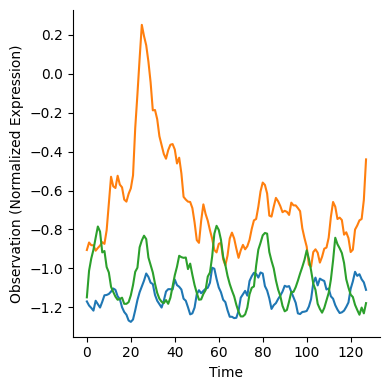

In [45]:
action= np.array([-1.        ,  1.        ,  0.18])
obs, info = env.reset(0)
env.uncertain = np.ones(4)
params_action = np.concatenate((env.uncertain, action))
reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
rew = np.clip(reward, -5, 5)

obs_vector = jl.observation(env.uncertain, action)
obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)
plt.figure(figsize=(4, 4))
plt.plot(obs_vector[0])

obs_vector = jl.observation(-np.ones(4), action)
obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

plt.plot(obs_vector[0])

obs_vector = jl.observation(np.zeros(4), action)
obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

plt.plot(obs_vector[0])

plt.xlabel("Time")
plt.ylabel("Observation (Normalized Expression)")

sns.despine()
plt.tight_layout()
plt.savefig("epistemic.pdf")


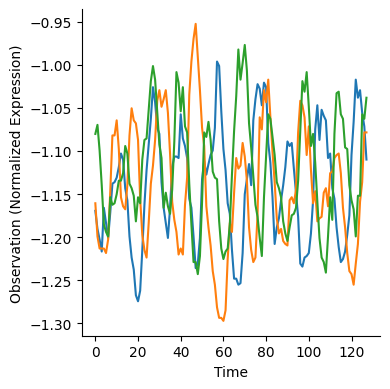

In [44]:
plt.figure(figsize=(4, 4))
obs, info = env.reset(0)
env.uncertain = np.ones(4)
params_action = np.concatenate((env.uncertain, action))
reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
rew = np.clip(reward, -5, 5)

obs_vector = jl.observation(env.uncertain, action)
obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

plt.plot(obs_vector[0])

obs_vector = jl.observation(env.uncertain, action)
obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

plt.plot(obs_vector[0])

obs_vector = jl.observation(env.uncertain, action)
obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

plt.plot(obs_vector[0])

plt.xlabel("Time")
plt.ylabel("Observation (Normalized Expression)")
sns.despine()
plt.tight_layout()
plt.savefig("aleatoric.pdf")
